In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

In [2]:
from jetnet.datasets import JetNet
from jetnet.datasets.normalisations import FeaturewiseLinearBounded, FeaturewiseLinear

/Users/arjunsharma/development/s25-fermilab-research/src/venv/lib/python3.9/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [3]:
MASK = True
NUM_PARTICLES = 30
TRAIN_SPLIT = 0.7

data_args = {
    "jet_type": ["g", "q", "t"],
    "data_dir": "datasets/jetnet",
    "num_particles": NUM_PARTICLES,
    "particle_features": (
        JetNet.ALL_PARTICLE_FEATURES if MASK else JetNet.ALL_PARTICLE_FEATURES[:-1]
    ),
    # The order of the list is preserved in the retrieved data
    "jet_features": ["eta", "pt", "mass", "num_particles", "type"],
    # "particle_normalisation": particle_normalizer,
    "split_fraction": [TRAIN_SPLIT, 1 - TRAIN_SPLIT, 0],
    "download": True
}

In [4]:
from util.coordinates import transform_rel_particle_coordinates_to_cartesian
X_train = JetNet(**data_args, split="train")
X_test = JetNet(**data_args, split="valid")
X_train_particle_transformed = transform_rel_particle_coordinates_to_cartesian(X_train)
X_test_particle_transformed = transform_rel_particle_coordinates_to_cartesian(X_test)

print(X_train_particle_transformed.shape)
print(X_test_particle_transformed.shape)

torch.Size([368113, 30, 4])
torch.Size([157763, 30, 4])


In [5]:
e_c = np.array(X_train_particle_transformed[:, :, 0].flatten())
p_x = np.array(X_train_particle_transformed[:, :, 1].flatten())
p_y = np.array(X_train_particle_transformed[:, :, 2].flatten())
p_z = np.array(X_train_particle_transformed[:, :, 3].flatten())

Text(0.5, 1.0, '$p_z$')

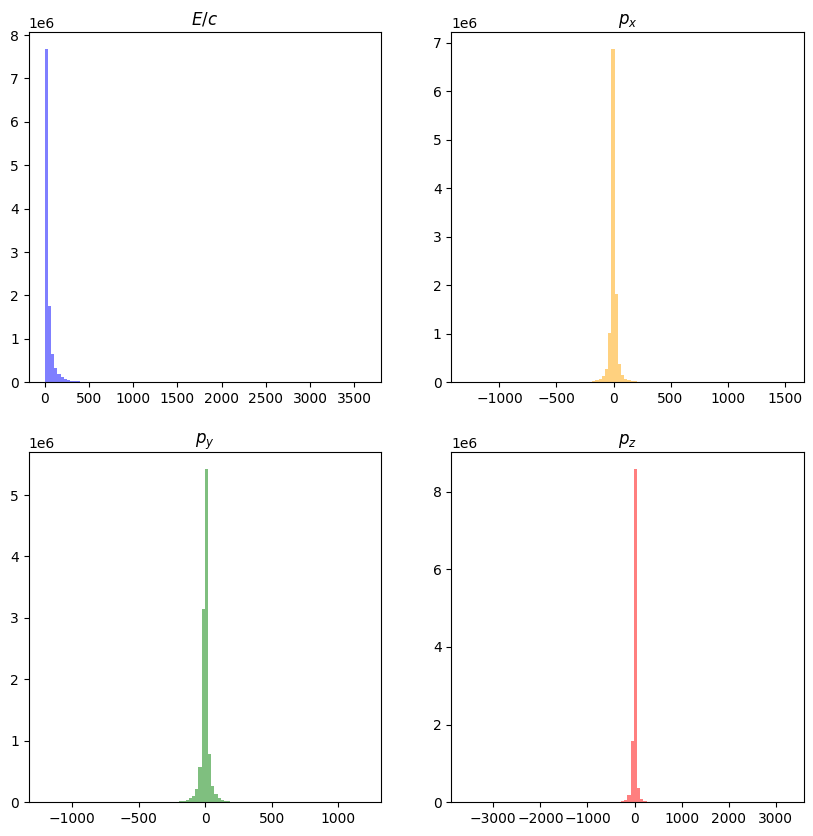

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs[0, 0].hist(e_c, bins=100, alpha=0.5, color='blue')
axs[0, 0].set_title(r'$E/c$')
axs[0, 1].hist(p_x, bins=100, alpha=0.5, color='orange')
axs[0, 1].set_title(r'$p_x$')
axs[1, 0].hist(p_y, bins=100, alpha=0.5, color='green')
axs[1, 0].set_title(r'$p_y$')
axs[1, 1].hist(p_z, bins=100, alpha=0.5, color='red')
axs[1, 1].set_title(r'$p_z$')

In [7]:
from scipy.stats import skew
e_c_mirrored = np.concatenate([e_c, -e_c])
skew(np.array(e_c_mirrored)), skew(np.array(p_x)), skew(np.array(p_y)), skew(np.array(p_z))

(6.117256875717103e-06,
 0.03575965790125095,
 0.057348069732147434,
 0.11670660321866663)

The data is fairly normally distributed, so we scale it by the calculated normal from the Anderson tests

In [8]:
from scipy.stats import anderson
and_ec = anderson(e_c_mirrored)
and_p_x = anderson(p_x)
and_p_y = anderson(p_y)
and_p_z = anderson(p_z)

and_ec, and_p_x, and_p_y, and_p_z

(AndersonResult(statistic=1895306.602869369, critical_values=array([0.576, 0.656, 0.787, 0.918, 1.092]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=2.8212578e-06, scale=89.71055)
  success: True
  message: '`anderson` successfully fit the distribution to the data.'),
 AndersonResult(statistic=1036540.3602174334, critical_values=array([0.576, 0.656, 0.787, 0.918, 1.092]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=0.044877723, scale=44.58109)
  success: True
  message: '`anderson` successfully fit the distribution to the data.'),
 AndersonResult(statistic=1032389.5267294496, critical_values=array([0.576, 0.656, 0.787, 0.918, 1.092]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=0.032353286, scale=44.685986)
  success: True
  message: '`anderson` successfully fit the distribution to the data.'),
 AndersonResult(statistic=1507250.5564268567, c

In [9]:
scales = [an.fit_result.params.scale for an in [and_ec, and_p_x, and_p_y, and_p_z]]
final_scale = np.min(scales)
scales, final_scale

([89.71055, 44.58109, 44.685986, 63.746887], 44.58109)

In [10]:
e_c, p_x, p_y, p_z = (1/final_scale * arr for arr in [e_c, p_x, p_y, p_z])

Text(0.5, 1.0, '$p_z$')

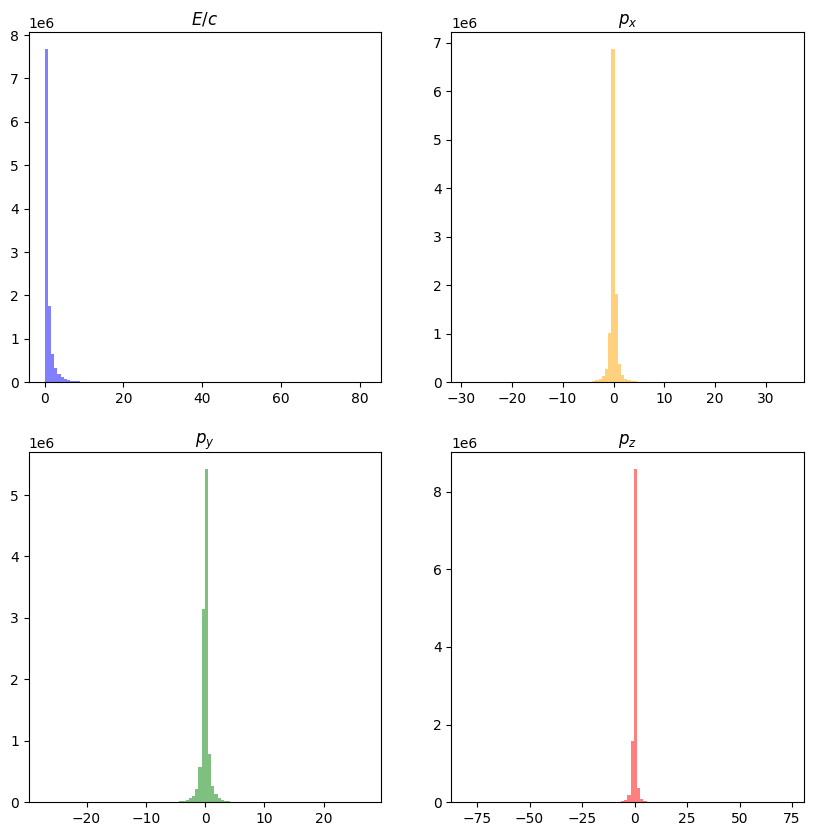

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs[0, 0].hist(e_c, bins=100, alpha=0.5, color='blue')
axs[0, 0].set_title(r'$E/c$')
axs[0, 1].hist(p_x, bins=100, alpha=0.5, color='orange')
axs[0, 1].set_title(r'$p_x$')
axs[1, 0].hist(p_y, bins=100, alpha=0.5, color='green')
axs[1, 0].set_title(r'$p_y$')
axs[1, 1].hist(p_z, bins=100, alpha=0.5, color='red')
axs[1, 1].set_title(r'$p_z$')

In [12]:
anderson(e_c), anderson(p_x), anderson(p_y), anderson(p_z)

(AndersonResult(statistic=1575602.1985242292, critical_values=array([0.576, 0.656, 0.787, 0.918, 1.092]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=0.96636295, scale=1.765077)
  success: True
  message: '`anderson` successfully fit the distribution to the data.'),
 AndersonResult(statistic=1036541.3184202854, critical_values=array([0.576, 0.656, 0.787, 0.918, 1.092]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=0.0010066527, scale=1.0000007)
  success: True
  message: '`anderson` successfully fit the distribution to the data.'),
 AndersonResult(statistic=1032389.8353641257, critical_values=array([0.576, 0.656, 0.787, 0.918, 1.092]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=0.0007257173, scale=1.0023532)
  success: True
  message: '`anderson` successfully fit the distribution to the data.'),
 AndersonResult(statistic=1507250.2107260954, 